# Pima Indians Diabetes Stacking Ensemble

## 개요
- Pima Indians Diabetes 데이터셋으로 **당뇨병 발병 여부** 예측
- Stacking Ensemble로 성능 향상 및 하이퍼파라미터 최적화(GridSearchCV)
- 평가 지표: **Accuracy**, **F1-Score**, **Classification Report**

## 주요 단계
1. 데이터 로드 및 분리
2. Stacking Classifier 설정 (Base Models + Meta Model)
3. GridSearchCV 최적화
4. 성능 평가 및 비교 분석

In [1]:
from readline import parse_and_bind

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# Base Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Stacking
from sklearn.ensemble import StackingClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

## 1. 데이터 로드

In [2]:
pima = fetch_openml('diabetes', version=1, as_frame=True)
X = pima.data
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")
print(f"\n클래스 비율:\n{y.value_counts(normalize=True)}")

데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64

클래스 비율:
class
0    0.651042
1    0.348958
Name: proportion, dtype: float64


## 2. 데이터 전처리 및 분할

In [3]:
# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"\ny_train 클래스 분포:\n{y_train.value_counts()}")
print(f"\ny_test 클래스 분포:\n{y_test.value_counts()}")

X_train: (614, 8), X_test: (154, 8)

y_train 클래스 분포:
class
0    400
1    214
Name: count, dtype: int64

y_test 클래스 분포:
class
0    100
1     54
Name: count, dtype: int64


## 3. Stacking Classifier 정의

**Stacking Ensemble 구조:**
- **Base Models (Level 0)**: 여러 개의 다양한 모델
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - SVC
- **Meta Model (Level 1)**: Base Models의 예측을 학습
  - Logistic Regression

In [4]:
# Base Models 정의
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss' ,random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42)),
]

In [5]:
# Meta Model 정의 -> 선형 모델이 좋음.
meta_model = LogisticRegression(max_iter=1000, random_state=42)

In [6]:
# Stacking Classifier 생성
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,   # K-Fold(교차검사)의 Fold 수
    n_jobs=-1,
)

## 4. 기본 모델 학습 및 평가

In [7]:
# 학습
stacking_clf.fit(X_train, y_train)

# 예측
y_pred_train = stacking_clf.predict(X_train)    # 훈련 성능 확인 목적
y_pred_test = stacking_clf.predict(X_test)

# 성능 평가 - overfitting이 일어났는지 확인
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

print("\n분류 리포트 (기본 모델):")
print(classification_report(y_test, y_pred_test, target_names=['No Diabetes', 'Diabetes']))

Train Accuracy: 0.8909
Test Accuracy: 0.7532
Test F1-Score: 0.6122

분류 리포트 (기본 모델):
              precision    recall  f1-score   support

 No Diabetes       0.78      0.86      0.82       100
    Diabetes       0.68      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



## 5. 교차 검증 - StratifiedKFold

In [8]:
# StratifiedKFold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 교차 검증 점수
cv_scores = cross_val_score(
    stacking_clf,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print(f"교차 검증 점수: {cv_scores}")
print(f"평균 정확도: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

교차 검증 점수: [0.77235772 0.7398374  0.79674797 0.75609756 0.7704918 ]
평균 정확도: 0.7671 (+/- 0.0189)


## 6. GridSearchCV 최적화하기

**하이퍼파라미터 튜닝**
- Meta Model의 파라미터 최적화
- 5-Fold Cross Validation

In [9]:
# 파라미터 그리드 - meta model의 규제 관련 후보
param_grid = {
    'final_estimator__C': [0.1, 1.0, 10.0], # LogisticRegression의 규제(과적합 방지 목적) 강도
    'final_estimator__penalty': ['l2'],     # LogisticRegression의 규제 방식 종류
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=stacking_clf,     # GridSearchCV가 최적화할 모델
    param_grid=param_grid,      # 탐색할 하이퍼파라미터 조합
    cv=5,   # Fold 개수
    scoring='accuracy',
    n_jobs=-1,  # 병렬 처리 cpu 개수
    verbose=1   # 학습 진행 상황 간단 로그
)

# 학습
grid_search.fit(X_train, y_train)

print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"최적 교차 검증 점수: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits

최적 파라미터: {'final_estimator__C': 10.0, 'final_estimator__penalty': 'l2'}
최적 교차 검증 점수: 0.7623


## 7. 최적 모델 평가

In [16]:
# 최적 모델 저장
best_model = grid_search.best_estimator_

# 테스트 데이터 예측
y_pred_best = best_model.predict(X_test)

# 성능 평가하기
test_acc_best = accuracy_score(y_test, y_pred_best)
test_f1_best = f1_score(y_test, y_pred_best)

print(f"\n최적화된 모델 테스트 정확도: {test_acc_best:.4f}")
print(f"최적화된 모델 테스트 F1-Score: {test_f1_best:.4f}")

print("\n분류 리포트 (최적화된 모델):")
print(classification_report(y_test, y_pred_best, target_names=['No Diabetes', 'Diabetes']))


최적화된 모델 테스트 정확도: 0.7597
최적화된 모델 테스트 F1-Score: 0.6263

분류 리포트 (최적화된 모델):
              precision    recall  f1-score   support

 No Diabetes       0.79      0.86      0.82       100
    Diabetes       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



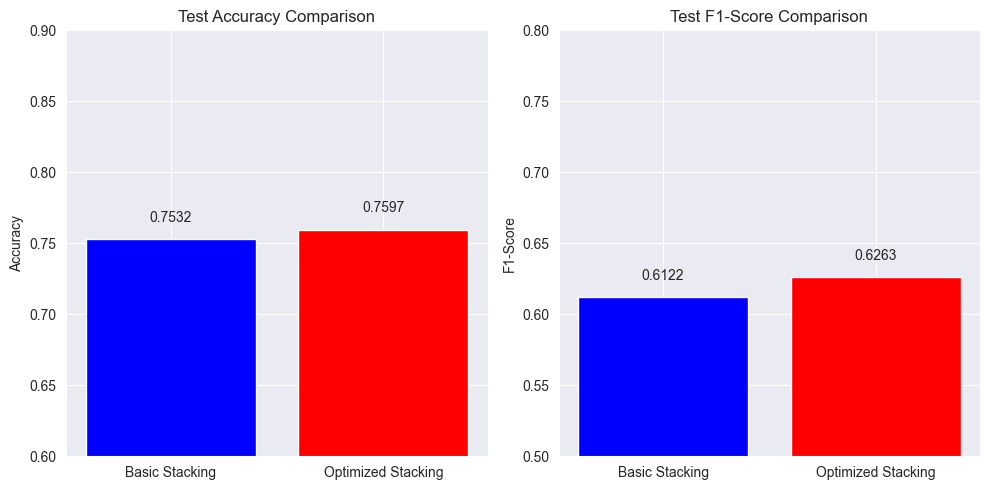

In [17]:
# 성능 비교하기
comp_df = pd.DataFrame({
    'Model': ['Basic Stacking', 'Optimized Stacking'],
    'Test Accuracy': [test_acc, test_acc_best],
    'Test F1-Score': [test_f1, test_f1_best]
})

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Accuracy 비교
axes[0].bar(comp_df['Model'], comp_df['Test Accuracy'], color=['blue','red'])
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.6, 0.9)
for i, v in enumerate(comp_df['Test Accuracy']):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom')

# F1-Score 비교
axes[1].bar(comp_df['Model'], comp_df['Test F1-Score'], color=['blue', 'red'])
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Test F1-Score Comparison')
axes[1].set_ylim([0.5, 0.8])
for i, v in enumerate(comp_df['Test F1-Score']):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 8. Base Models 개별 성능 분석

In [18]:
base_results = []

for name, model in base_models:
    # 학습
    model.fit(X_train, y_train)

    # 예측 및 평가
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    base_results.append({
        'Model': name.upper(),
        'Test Accuracy': acc,
        'Test F1-Score': f1,
    })

    print(f"{name.upper():<10} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

base_results_df = pd.DataFrame(base_results)

print(f"\nStacking Ensemble | Accuracy: {test_acc_best:.4f} | F1-Score: {test_f1_best:.4f}")
print("\n→ Stacking은 Base Models의 강점을 결합하여 성능을 향상시킵니다.")

RF         | Accuracy: 0.7727 | F1-Score: 0.6465
GB         | Accuracy: 0.7532 | F1-Score: 0.6275
XGB        | Accuracy: 0.7338 | F1-Score: 0.6168
LGBM       | Accuracy: 0.7468 | F1-Score: 0.6214
SVC        | Accuracy: 0.7208 | F1-Score: 0.5169

Stacking Ensemble | Accuracy: 0.7597 | F1-Score: 0.6263

→ Stacking은 Base Models의 강점을 결합하여 성능을 향상시킵니다.


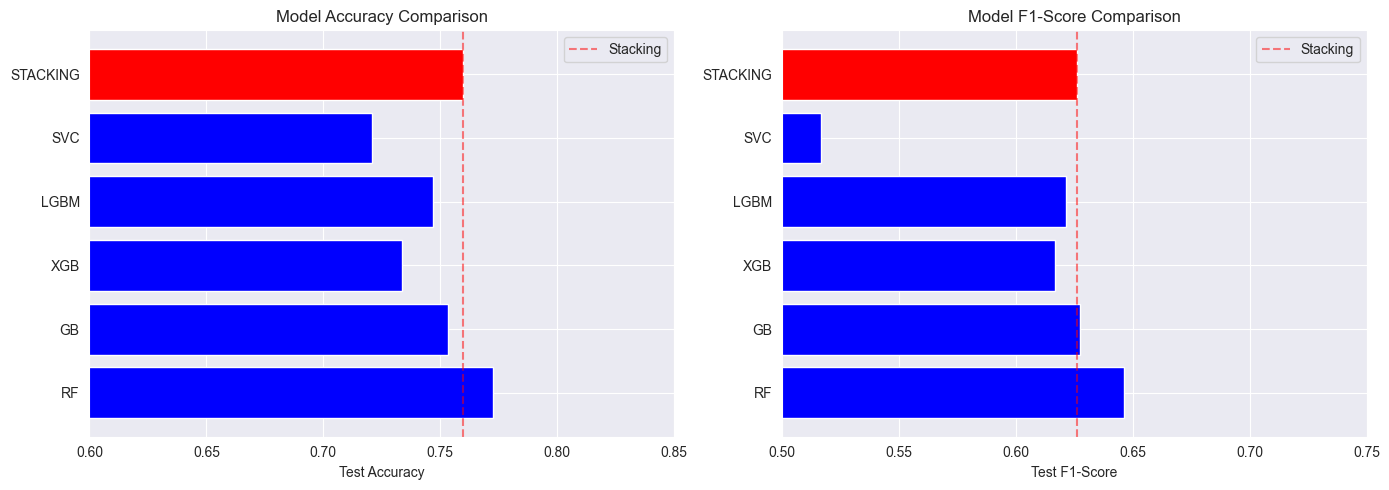

In [19]:
# Base Models vs Stacking 시각화
all_results = pd.concat([base_results_df, pd.DataFrame([{
    'Model': 'STACKING',
    'Test Accuracy': test_acc_best,
    'Test F1-Score': test_f1_best
}])], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy 비교
colors = ['blue'] * len(base_results) + ['red']
axes[0].barh(all_results['Model'], all_results['Test Accuracy'], color=colors)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlim([0.6, 0.85])
axes[0].axvline(x=test_acc_best, color='red', linestyle='--', alpha=0.5, label='Stacking')
axes[0].legend()

# F1-Score 비교
axes[1].barh(all_results['Model'], all_results['Test F1-Score'], color=colors)
axes[1].set_xlabel('Test F1-Score')
axes[1].set_title('Model F1-Score Comparison')
axes[1].set_xlim([0.5, 0.75])
axes[1].axvline(x=test_f1_best, color='red', linestyle='--', alpha=0.5, label='Stacking')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Feature 중요도 분석

Stacking의 Base Model 중 성능이 가장 좋았던 Random Forest의 feature 중요도 분석해보기

In [22]:
# Random Forest 모델 추출
rf_model = best_model.estimators_[0][1]

# feature 명
feature_names = X.columns

# feature 중요도 추출
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1] # 중요도 높은 feature 순으로 인덱스 정렬

importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("피처 중요도 순위:")
print(importance_df.to_string(index=False))

피처 중요도 순위:
Feature  Importance
   plas    0.312721
    age    0.214551
   mass    0.139520
   pedi    0.120831
   pres    0.079770
   preg    0.057748
   skin    0.048830
   insu    0.026028


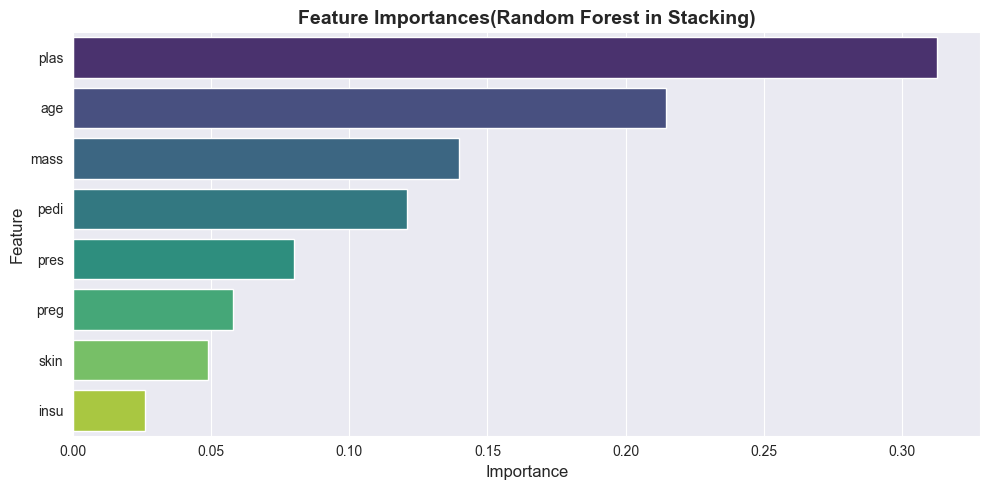

In [23]:
# 피처 중요도 순위 시각화
plt.figure(figsize=(10, 5))
sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'], palette='viridis')
plt.title('Feature Importances(Random Forest in Stacking)', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()